# Problem Analysis Workshop A
**PROG8431 · Group 5**

| Team member | Student ID |
|:--|--:|
| Asangika Hettiarachchi | 7461502 |
| Juan Antonio Sainz Galvez | 9072844 |
| Ved Patel | 9111628 |

## Research question
**Do the distributions of recorded property prices differ between Downtown Toronto and Mississauga?**

We examine the same numerical variable, **Price ($)**, throughout. Histograms and QQ plots describe its distribution; Shapiro–Wilk assesses normality; the F-test compares sample variances. **Wilcoxon rank-sum / Mann–Whitney U compares the groups; Z-scores describe individual prices relative to their group.** All hypothesis tests are two-sided, with a significance level of **0.05**.

**Source:** [Ontario Residential Property Data — Kaggle](https://www.kaggle.com/datasets/mnabaee/ontarioproperties). The supplied file is stored as `data/properties.csv`.

## 1. Setup
Run the cells in order. The code reads the supplied CSV and produces all tables, figures, and test results. Prices remain in dollars for calculations; chart axes use millions of dollars for readability.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display
from scipy import stats

ALPHA = 0.05
COLORS = {"Downtown": "#2563a6", "Mississauga": "#d07a25"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 13,
    "axes.labelsize": 11, "axes.spines.top": False,
    "axes.spines.right": False, "axes.axisbelow": True,
})
pd.set_option("display.max_columns", 10)

## 2. Read the data and define the groups
Each row is a property record. `AreaName` identifies the comparison groups, and `Price ($)` supplies the measurement. `Address`, `lat`, and `lng` provide location information. The exported index is not a measurement.

The existing selection rule is retained. Records are selected by the exact area labels **Downtown** and **Mississauga**. No duplicate records are removed in this revision.

In [2]:
# Support launching from this folder, its parent, or the repository root.
candidate_paths = [
    Path("data/properties.csv"),
    Path("ProblemAnalysisWorkshopA/data/properties.csv"),
    Path("C:/AI/PROG8431/ProblemAnalysisWorkshop/ProblemAnalysisWorkshopA/data/properties.csv"),
]
data_path = next((p for p in candidate_paths if p.is_file()), None)
if data_path is None:
    raise FileNotFoundError("Open the workshop folder containing data/properties.csv.")

raw_data = pd.read_csv(data_path)
property_data = raw_data.loc[raw_data["Price ($)"] > 100_000].copy()
property_data = property_data.drop(columns=["Unnamed: 0"], errors="ignore")
downtown_prices = property_data.loc[
    property_data["AreaName"].eq("Downtown"), "Price ($)"
].dropna()
mississauga_prices = property_data.loc[
    property_data["AreaName"].eq("Mississauga"), "Price ($)"
].dropna()
groups = {"Downtown": downtown_prices, "Mississauga": mississauga_prices}
assert all(len(values) > 1 for values in groups.values())

print(f"Original records: {len(raw_data):,}")
print(f"Records after selection: {len(property_data):,}")
print(f"Records in the two comparison groups: {sum(map(len, groups.values())):,}")
display(property_data.head())

Original records: 25,351
Records after selection: 22,673
Records in the two comparison groups: 1,494


,Address,AreaName,Price ($),lat,lng
0,"86 Waterford Dr Toronto, ON",Richview,999888,43.679882,-79.544266
1,"#80 - 100 BEDDOE DR Hamilton, ON",Chedoke Park B,399900,43.250000,-79.904396
2,"213 Bowman Street Hamilton, ON",Ainslie Wood East,479000,43.251690,-79.919357
3,"102 NEIL Avenue Hamilton, ON",Greenford,285900,43.227161,-79.767403
4,"#1409 - 230 King St Toronto, ON",Downtown,362000,43.651478,-79.368118


### Group summary
The **mean** is the arithmetic average. The **median** is the middle price and is less sensitive to unusually expensive records. The **standard deviation** measures spread around the mean. The **interquartile range (IQR)** covers the middle 50% of prices.

In [3]:
summary = pd.DataFrame({
    name: {
        "Records": len(values), "Mean": values.mean(),
        "Median": values.median(), "Standard deviation": values.std(ddof=1),
        "Q1": values.quantile(0.25), "Q3": values.quantile(0.75),
        "IQR": values.quantile(0.75) - values.quantile(0.25),
    } for name, values in groups.items()
}).T
summary.index = ["Downtown Toronto", "Mississauga"]
display(summary.style.format({
    "Records": "{:,.0f}",
    **{column: "${:,.0f}" for column in summary.columns if column != "Records"},
}).set_caption("Recorded property prices by area (CAD)"))

# Review checks only: these records remain in the analysis.
duplicate_counts = {
    name: property_data.loc[property_data["AreaName"].eq(name)].duplicated().sum()
    for name in groups
}
print("Exact duplicate rows, excluding the exported index:", duplicate_counts)

,Records,Mean,Median,Standard deviation,Q1,Q3,IQR
Downtown Toronto,788,"$619,496","$470,000","$672,054","$384,900","$628,000","$243,100"
Mississauga,706,"$650,706","$389,900","$939,103","$295,972","$579,900","$283,928"


Exact duplicate rows, excluding the exported index: {'Downtown': np.int64(14), 'Mississauga': np.int64(13)}


### Independence assumption
Mann–Whitney U and the classical F-test assume independent observations. Different area labels do not establish independence. Exact duplicates remain in both groups, and nearby properties may share market conditions. The dataset does not establish a random sampling design. Interpret the tests conditionally on the independence assumption; confirm whether duplicate records represent repeated listings before making a stronger inference.

## 3. Explore the price distributions
The first histogram includes **every selected Ontario record**. The second figure compares the two groups using identical price bins. All prices are retained in both figures. The comparison histogram uses a logarithmic frequency axis so the long tails remain visible.

The box plot shows medians, quartiles, and extreme values. Its logarithmic price axis compresses the wide price range; it does not change the data used in the tests.

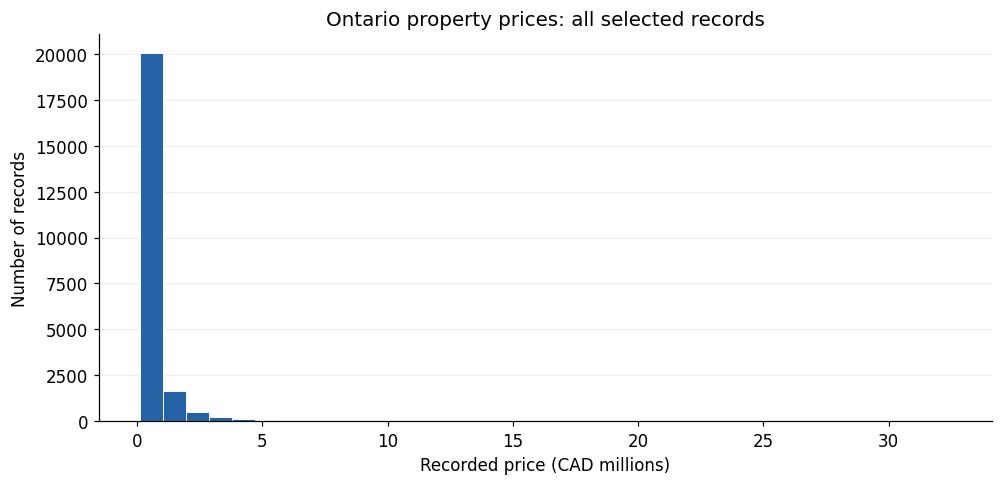

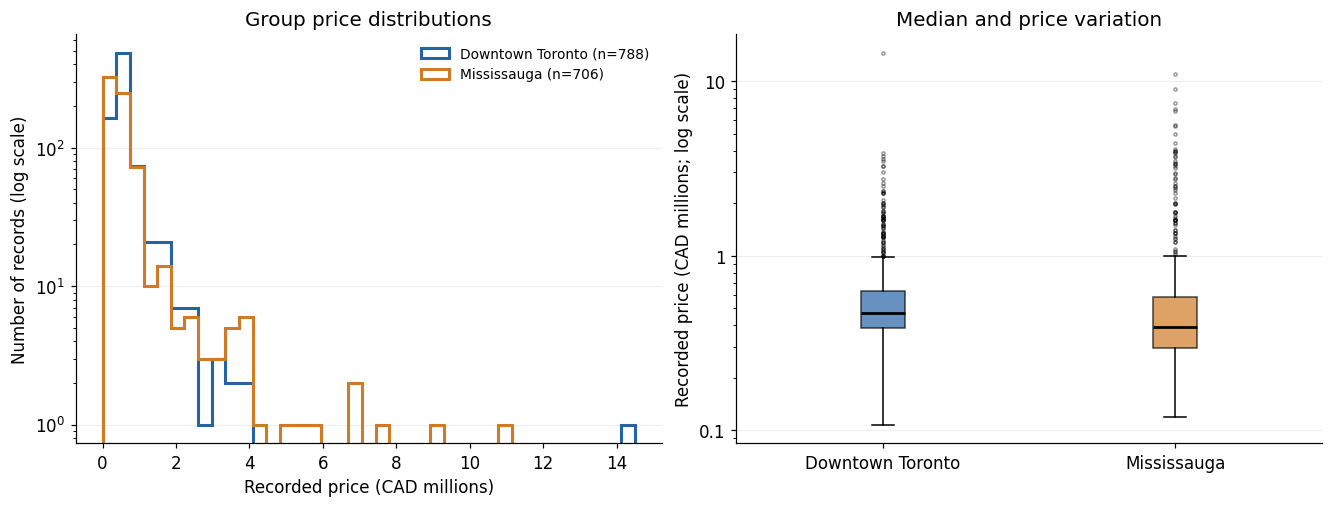

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.3), layout="constrained")
ax.hist(property_data["Price ($)"] / 1_000_000, bins=35,
        color="#2563a6", edgecolor="white", linewidth=0.6)
ax.set(title="Ontario property prices: all selected records",
       xlabel="Recorded price (CAD millions)", ylabel="Number of records")
ax.grid(axis="y", alpha=0.2)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
bins = np.linspace(0, max(v.max() for v in groups.values()) / 1_000_000, 40)
for name, values in groups.items():
    label = "Downtown Toronto" if name == "Downtown" else name
    axes[0].hist(values / 1_000_000, bins=bins, histtype="step",
                 linewidth=2, color=COLORS[name], label=f"{label} (n={len(values):,})")
axes[0].set(title="Group price distributions", xlabel="Recorded price (CAD millions)",
            ylabel="Number of records (log scale)", yscale="log")
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(axis="y", alpha=0.2)

boxes = axes[1].boxplot([v / 1_000_000 for v in groups.values()],
                       tick_labels=["Downtown Toronto", "Mississauga"], patch_artist=True,
                       flierprops={"marker": ".", "markersize": 4, "alpha": 0.4})
for patch, color in zip(boxes["boxes"], COLORS.values()):
    patch.set(facecolor=color, alpha=0.7)
for line in boxes["medians"]:
    line.set(color="black", linewidth=1.8)
axes[1].set(title="Median and price variation", ylabel="Recorded price (CAD millions; log scale)",
            yscale="log")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:g}"))
axes[1].grid(axis="y", alpha=0.2)
plt.show()

### Reading the figures
Most prices lie toward the lower end, with a long tail of expensive records. Means and medians can therefore tell different stories: Mississauga has the higher mean, while Downtown has the higher median. The rank-based comparison below does not directly test mean prices; medians remain useful descriptive summaries.

## 4. Normality: QQ plots and Shapiro–Wilk
**H₀:** The price distribution is normal.  
**H₁:** The price distribution is not normal.

A QQ plot compares observed prices with theoretical normal quantiles. Approximate normality would produce points near the reference line. Shapiro–Wilk supplies the statistic **W** and a p-value. A p-value below 0.05 supports rejecting H₀; a larger value does not prove normality.

We assess the full selected dataset and each comparison group. SciPy cautions that Shapiro–Wilk p-values may be inaccurate for samples above 5,000, which affects the full dataset but not these two groups.

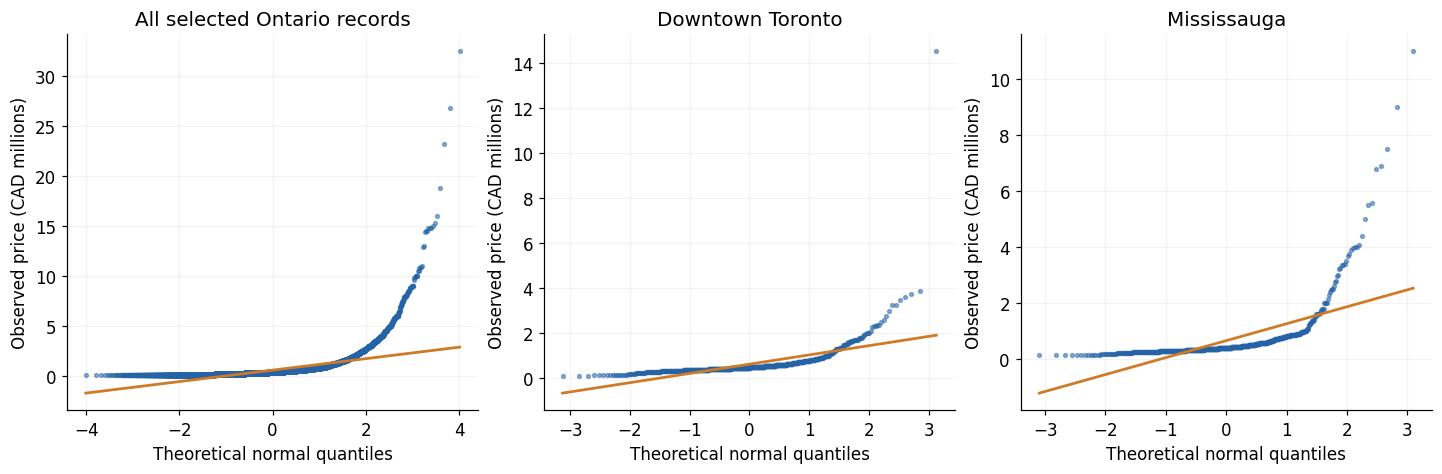

,Records,W,p-value,Decision
Sample,,,,
All selected Ontario records,"22,673",0.4297,2.11e-123,Reject normality
Downtown Toronto,788,0.3784,1.64e-45,Reject normality
Mississauga,706,0.4180,1.15e-42,Reject normality


SciPy limitation: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 22673.


In [5]:
normality_samples = {
    "All selected Ontario records": property_data["Price ($)"].dropna(),
    "Downtown Toronto": downtown_prices,
    "Mississauga": mississauga_prices,
}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), layout="constrained")
for ax, (name, values) in zip(axes, normality_samples.items()):
    stats.probplot(values / 1_000_000, dist="norm", plot=ax)
    ax.get_lines()[0].set(markersize=2.5, alpha=0.5, color="#2563a6")
    ax.get_lines()[1].set(color="#d07a25", linewidth=1.8)
    ax.set(title=name, xlabel="Theoretical normal quantiles",
           ylabel="Observed price (CAD millions)")
    ax.grid(alpha=0.15)
plt.show()

normality_rows = []
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always", UserWarning)
    for name, values in normality_samples.items():
        result = stats.shapiro(values / 1_000_000)
        normality_rows.append({"Sample": name, "Records": len(values),
                               "W": result.statistic, "p-value": result.pvalue,
                               "Decision": "Reject normality" if result.pvalue < ALPHA
                                           else "Fail to reject normality"})
normality_results = pd.DataFrame(normality_rows).set_index("Sample")
display(normality_results.style.format({"Records": "{:,.0f}", "W": "{:.4f}", "p-value": "{:.2e}"}))
for message in dict.fromkeys(str(w.message) for w in caught):
    print("SciPy limitation:", message)

### Normality interpretation (100 words)

Property prices show a pronounced right skew in the histogram and depart substantially from the normal reference line in the QQ plot. Across 22,673 filtered records, Shapiro–Wilk gives W = 0.4297 and p = 2.11e-123. At the 0.05 significance level, this supports rejecting normality. However, SciPy warns that its p-value may be inaccurate above 5,000 observations, so the visual evidence is also important. Group diagnostics should be considered separately because the comparison concerns Downtown Toronto and Mississauga. These findings require caution when interpreting parametric results. Neither a normality test nor a large sample establishes independence between the individual property records.

## 5. F-test: comparison of variances
**H₀:** Downtown Toronto and Mississauga have equal price variances.  
**H₁:** Their price variances differ.

Sample variance uses the sum of squared deviations from the group mean, divided by **n − 1**. We calculate:

$$F = \frac{s^2_{\mathrm{Mississauga}}}{s^2_{\mathrm{Downtown}}}.$$

The numerator degrees of freedom belong to Mississauga; the denominator degrees of freedom belong to Downtown. For a two-sided test, double the smaller tail probability. The survival function calculates the upper tail directly, avoiding numerical rounding to zero.

**Assumption limitation:** The classical F-test requires independent, normally distributed observations. These prices are non-normal, so its nominal p-value is presented as the required calculation, with this limitation, rather than decisive evidence of population variance differences.

In [6]:
downtown_variance = downtown_prices.var(ddof=1)
mississauga_variance = mississauga_prices.var(ddof=1)
f_statistic = mississauga_variance / downtown_variance
df_numerator = len(mississauga_prices) - 1
df_denominator = len(downtown_prices) - 1
f_p_value = min(1.0, 2 * min(
    stats.f.cdf(f_statistic, df_numerator, df_denominator),
    stats.f.sf(f_statistic, df_numerator, df_denominator),
))

print(f"Downtown sample variance: {downtown_variance:,.2f} CAD squared")
print(f"Mississauga sample variance: {mississauga_variance:,.2f} CAD squared")
print(f"F = {f_statistic:.4f}")
print(f"Degrees of freedom: {df_numerator} (numerator), {df_denominator} (denominator)")
print(f"Two-sided p-value = {f_p_value:.2e}")
print("Decision under F-test assumptions:",
      "Reject equal variances." if f_p_value < ALPHA else "Fail to reject equal variances.")
print("Caution: non-normal prices limit the validity of this nominal p-value.")

Downtown sample variance: 451,656,160,014.66 CAD squared
Mississauga sample variance: 881,914,341,378.88 CAD squared
F = 1.9526
Degrees of freedom: 705 (numerator), 787 (denominator)
Two-sided p-value = 9.49e-20
Decision under F-test assumptions: Reject equal variances.
Caution: non-normal prices limit the validity of this nominal p-value.


### F-test interpretation (50 words)

Mississauga’s sample variance is 1.9526 times Downtown Toronto’s. Using degrees of freedom 705 and 787, the calculated two-sided p-value is 9.49e-20. Under the classical F-test assumptions, equal variances are rejected. Because the price distributions are non-normal, this p-value requires caution. The variance ratio describes spread, not differences in typical prices.

### Shapiro–Wilk rubric summary (50 words)

Shapiro–Wilk and the QQ plots show that recorded prices depart from normality, with long upper tails. Group samples are below 5,000, while the full dataset exceeds SciPy’s recommended threshold for accurate p-values. Non-normality limits the classical F-test. A rank-based comparison avoids assuming normal prices, but still requires sufficiently independent observations.

## 6. Z-score: an individual price within Downtown
A Z-score describes how far one observation lies from its group mean in standard-deviation units:

$$z = \frac{x-\bar{x}}{s}.$$

We select the actual recorded Downtown price closest to its sample median as a transparent example. A positive score is above the mean; a negative score is below it. This is descriptive standardization, not a hypothesis test. Non-normal prices do not justify normal percentile interpretations.

In [7]:
# Select an actual observed price closest to the group median.
example_position = np.argmin(np.abs(downtown_prices.to_numpy() - downtown_prices.median()))
example_price = float(downtown_prices.iloc[example_position])
downtown_mean = downtown_prices.mean()
downtown_sd = downtown_prices.std(ddof=1)
z_score = (example_price - downtown_mean) / downtown_sd
print(f"Example recorded price: ${example_price:,.0f}")
print(f"Downtown mean: ${downtown_mean:,.2f}")
print(f"Downtown sample standard deviation: ${downtown_sd:,.2f}")
print(f"Z = ({example_price:,.0f} − {downtown_mean:,.2f}) / {downtown_sd:,.2f}")
print(f"Z-score = {z_score:.3f}")

Example recorded price: $470,000
Downtown mean: $619,496.42
Downtown sample standard deviation: $672,053.69
Z = (470,000 − 619,496.42) / 672,053.69
Z-score = -0.222


### Z-score interpretation (50 words)

A recorded Downtown property priced at $470,000 has a Z-score of -0.222. It lies below its group mean by 0.22 sample standard deviations. This standardization describes relative price within Downtown. Because prices are non-normal, the score should not be converted into a normal-distribution percentile or interpreted as an outlier rule.

## 7. Wilcoxon rank-sum / Mann–Whitney U test

The normality analysis shows that property prices are strongly skewed. We therefore use the Wilcoxon rank-sum / Mann–Whitney U test to compare the two groups without assuming normally distributed prices.

This is an independent-sample, rank-based comparison. It differs from the paired Wilcoxon signed-rank test.

**H₀:** The two groups have the same price distribution.  
**H₁:** Their price distributions differ.

The calculation combines the observations, ranks prices from lowest to highest, assigns average ranks to ties, and uses Downtown’s rank sum to obtain:

$$U_D = R_D - \frac{n_D(n_D + 1)}{2}.$$

SciPy computes a two-sided, asymptotic p-value with corrections for ties and continuity. The test still assumes independent observations. It does not directly test mean differences. A median-shift interpretation requires additional assumptions about distribution shapes, so our conclusion concerns price distributions.

In [8]:
n_downtown = len(downtown_prices)
n_mississauga = len(mississauga_prices)
combined_prices = np.concatenate([downtown_prices, mississauga_prices])
combined_ranks = stats.rankdata(combined_prices, method="average")
downtown_rank_sum = combined_ranks[:n_downtown].sum()
u_from_ranks = downtown_rank_sum - n_downtown * (n_downtown + 1) / 2

mw_result = stats.mannwhitneyu(
    downtown_prices, mississauga_prices,
    alternative="two-sided", method="asymptotic", use_continuity=True,
)
assert np.isclose(u_from_ranks, mw_result.statistic)
print(f"Group sizes: Downtown = {n_downtown:,}; Mississauga = {n_mississauga:,}")
print(f"Downtown rank sum = {downtown_rank_sum:,.1f}")
print(f"U = {downtown_rank_sum:,.1f} − {n_downtown} × {n_downtown + 1} / 2")
print(f"Mann–Whitney U = {mw_result.statistic:,.1f}")
print(f"Two-sided p-value = {mw_result.pvalue:.2e}")
print("Decision:", "Reject H0: evidence of different price distributions."
      if mw_result.pvalue < ALPHA else "Fail to reject H0: insufficient evidence of different distributions.")

Group sizes: Downtown = 788; Mississauga = 706
Downtown rank sum = 649,592.5
U = 649,592.5 − 788 × 789 / 2
Mann–Whitney U = 338,726.5
Two-sided p-value = 3.47e-13
Decision: Reject H0: evidence of different price distributions.


### Wilcoxon rank-sum / Mann–Whitney U interpretation (50 words)

Mann–Whitney U gives U = 338,726.5 and p = 3.47e-13, indicating different price distributions at the 0.05 level, assuming independent observations in this dataset. Downtown’s median is $470,000, versus $389,900 in Mississauga. This rank-based result does not establish a difference in mean prices or an effect caused solely by location.

## Conclusion
The selected Downtown Toronto and Mississauga records show different price distributions under the Mann–Whitney test, conditional on independence. Downtown has a higher observed median, while Mississauga has a higher observed mean and greater sample variation. These are distinct summaries of skewed prices.

The result describes this dataset. It does not establish that location causes a price difference. The classical F-test has a normality limitation, and duplicate observations remain a point for team review.